# data handling and processing

In [673]:
# basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [674]:
# load datasets
energy = pd.read_csv('/content/mumbai energy.csv')
population = pd.read_csv('/content/mumbai population.csv')
waste = pd.read_csv('/content/mumbai solid waste.csv')
water = pd.read_csv('/content/mumbai water consumption and waste.csv')
# preview
energy.head()
population.head()
waste.head()
water.head()

,Year,Consumption (MLD),Sewage (MLD),Data Source
0,2000,"2,950","1,975",ESR 2000 / BMC Hydraulic Dept
1,2001,"2,985","2,190",ESR 2001 / BMC Hydraulic Dept
2,2002,"3,010","2,265",ESR 2002
3,2003,"3,050","2,350",ESR 2003
4,2004,"3,100","2,410",ESR 2004


In [675]:
# clean column names
def clean_cols(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    return df

energy = clean_cols(energy)
population = clean_cols(population)
waste = clean_cols(waste)
water = clean_cols(water)

In [676]:
# rename for simplicity
energy = energy.rename(columns={'usage_(million_units_-_mu)': 'energy'})
population = population.rename(columns={'population_(millions)': 'population'})
waste = waste.rename(columns={'waste_(metric_tons/day)': 'waste'})
water = water.rename(columns={'consumption_(mld)': 'water'})
water = water.rename(columns={'sewage_(mld)': 'sewage'})

In [677]:
# remove extra columns
population = population.drop(columns=['data_source'], errors='ignore')
waste = waste.drop(columns=['data_source'], errors='ignore')
water = water.drop(columns=['data_source'], errors='ignore')
energy = energy.drop(columns=['data_source'], errors='ignore')
# merge all
df = energy.merge(population, on='year') \
           .merge(waste, on='year') \
           .merge(water, on='year')

df = df.sort_values('year').reset_index(drop=True)
df.head()

,year,energy,population,waste,water,sewage
0,2000,"7,120",16.15,"5,500","2,950","1,975"
1,2001,"7,245",16.50,"5,650","2,985","2,190"
2,2002,"7,380",16.68,"5,800","3,010","2,265"
3,2003,"7,510",16.87,"6,000","3,050","2,350"
4,2004,"7,650",17.06,"6,250","3,100","2,410"


In [678]:
# convert to numeric
df['energy'] = df['energy'].astype(str).str.replace(',', '').astype(float)
df['water'] = df['water'].astype(str).str.replace(',', '').astype(float)
df['waste'] = df['waste'].astype(str).str.replace(',', '').astype(float)
df['sewage'] = df['sewage'].astype(str).str.replace(',', '').astype(float)

In [679]:
# fill missing values
df = df.fillna(method='ffill')

/tmp/ipykernel_7106/2711284950.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


# Exploratory Data Analysis (EDA)

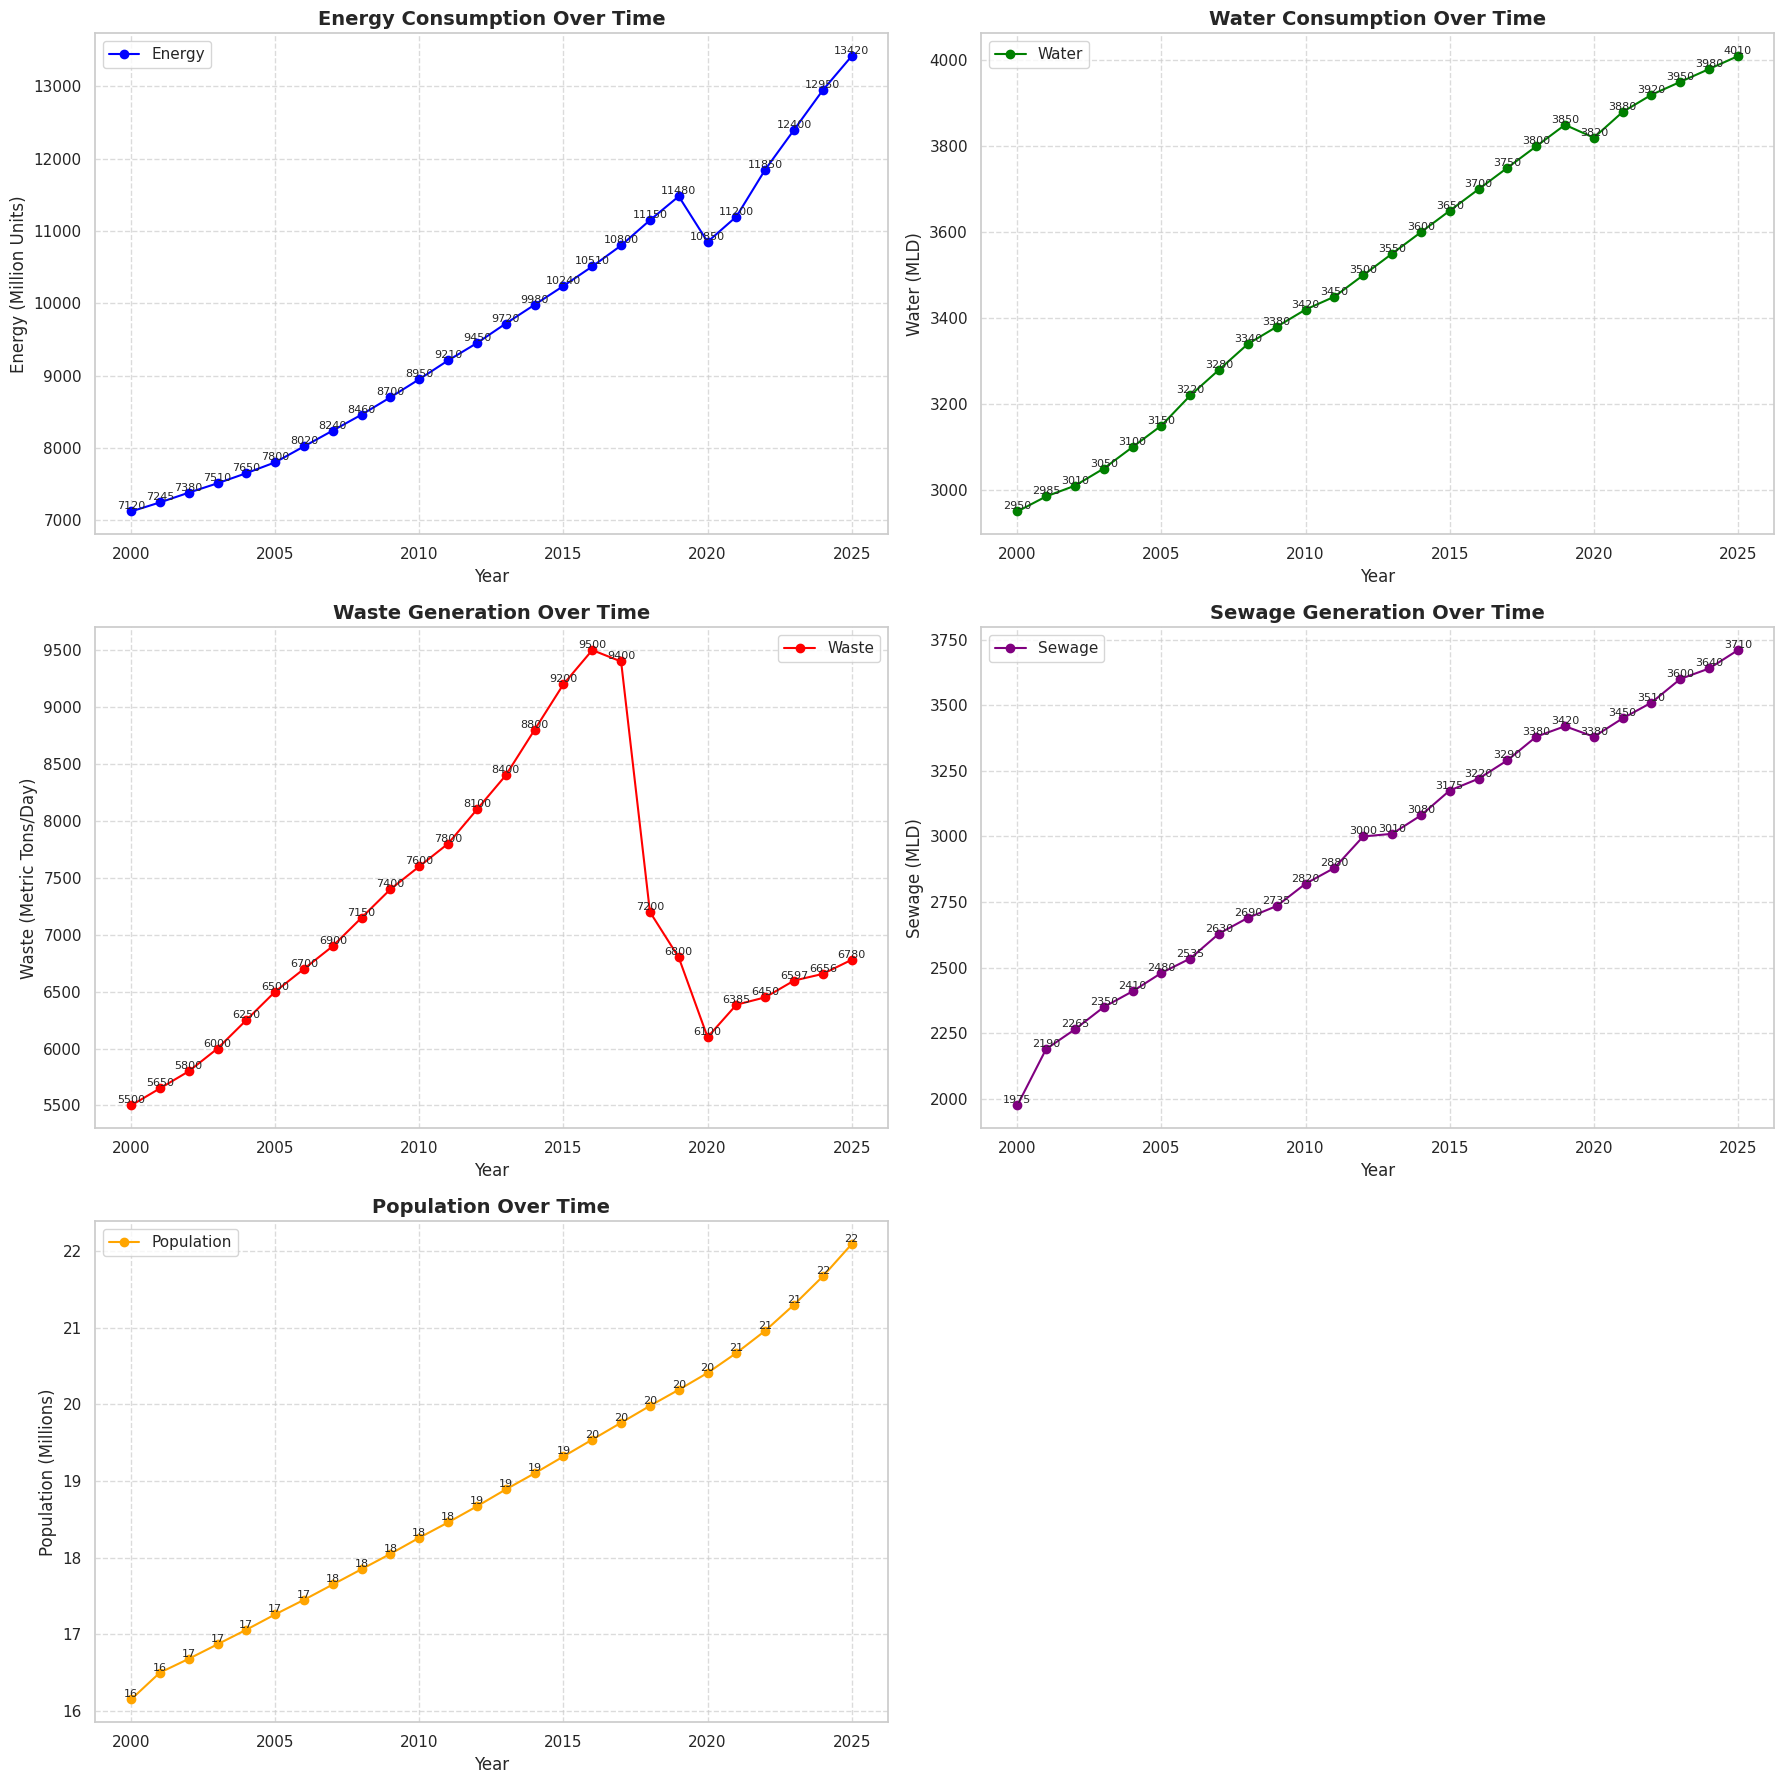

In [680]:
# plot all trends together
plt.figure(figsize=(18, 18)) # Increased figure height to accommodate more plots

# plot function to avoid repetition
def plot_trend(position, x, y, title, ylabel, color):
    plt.subplot(3, 2, position) # Changed grid from 2x2 to 3x2
    plt.plot(x, y, marker='o', color=color, label=title.split()[0])

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # add value labels
    for i in range(len(x)):
        plt.text(x[i], y[i], f"{y[i]:.0f}", fontsize=8, ha='center', va='bottom')

# energy
plot_trend(1, df['year'], df['energy'],
           "Energy Consumption Over Time", "Energy (Million Units)", 'blue')

# water
plot_trend(2, df['year'], df['water'],
           "Water Consumption Over Time", "Water (MLD)", 'green')

# waste
plot_trend(3, df['year'], df['waste'],
           "Waste Generation Over Time", "Waste (Metric Tons/Day)", 'red')

# sewage
plot_trend(4, df['year'], df['sewage'],
           "Sewage Generation Over Time", "Sewage (MLD)", 'purple')

#population
plot_trend(5, df['year'], df['population'],
           "Population Over Time", "Population (Millions)", 'orange')

plt.tight_layout()
plt.show()

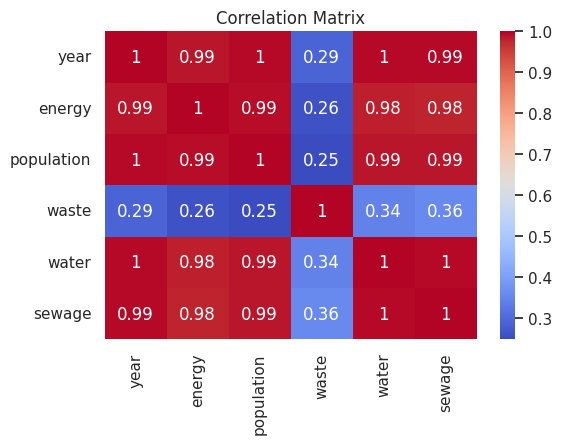

In [681]:
# correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

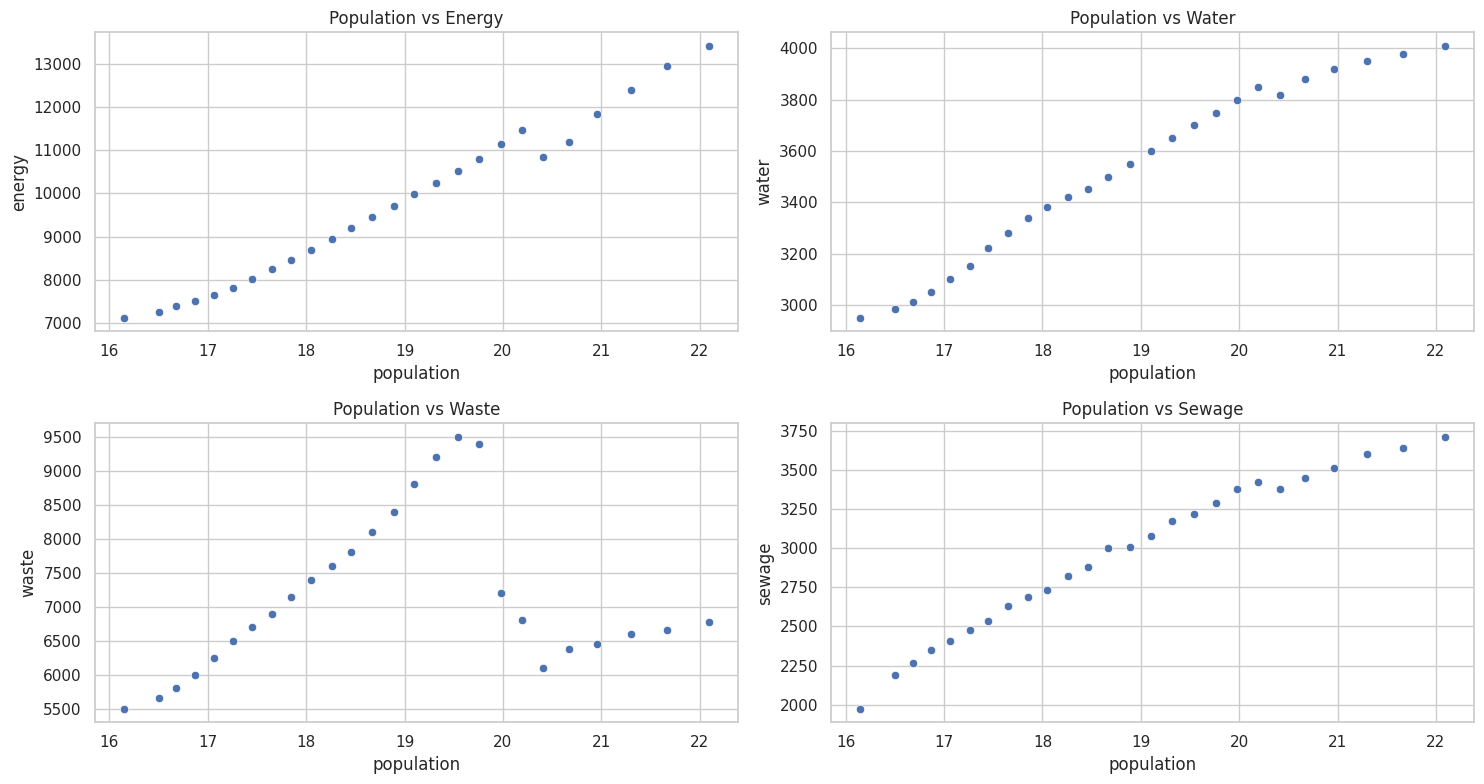

In [682]:
# population vs resources
plt.figure(figsize=(15,8))

plt.subplot(2,2,1)
sns.scatterplot(x='population', y='energy', data=df)
plt.title('Population vs Energy')

plt.subplot(2,2,2)
sns.scatterplot(x='population', y='water', data=df)
plt.title('Population vs Water')

plt.subplot(2,2,3)
sns.scatterplot(x='population', y='waste', data=df)
plt.title('Population vs Waste')

plt.subplot(2,2,4)
sns.scatterplot(x='population', y='sewage', data=df)
plt.title('Population vs Sewage')

plt.tight_layout()
plt.show()

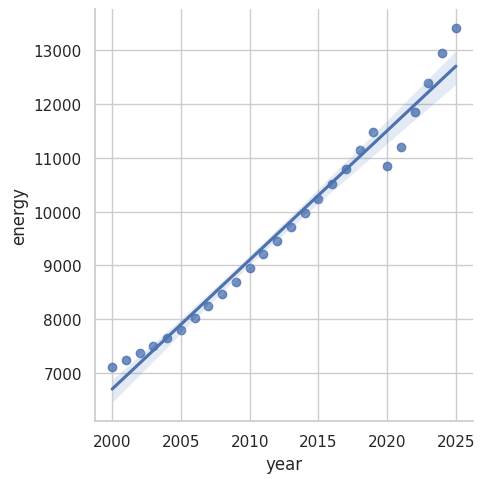

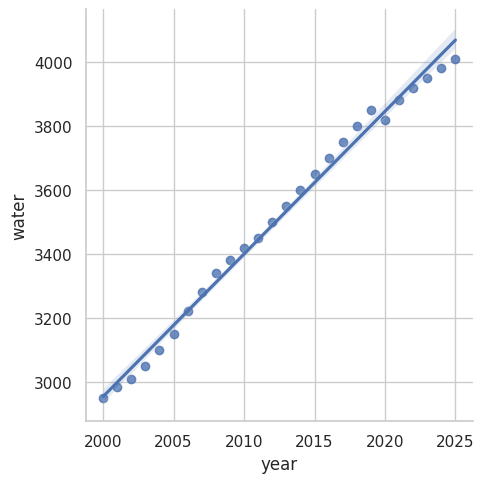

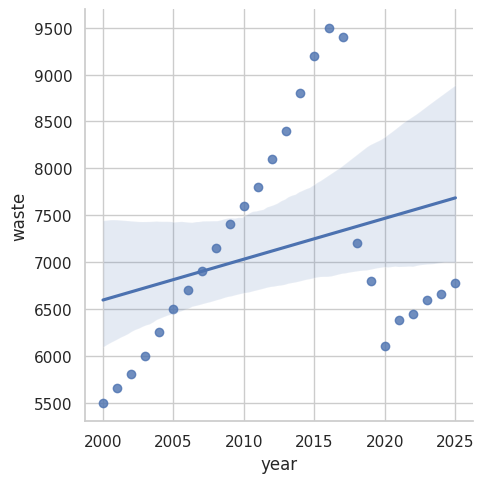

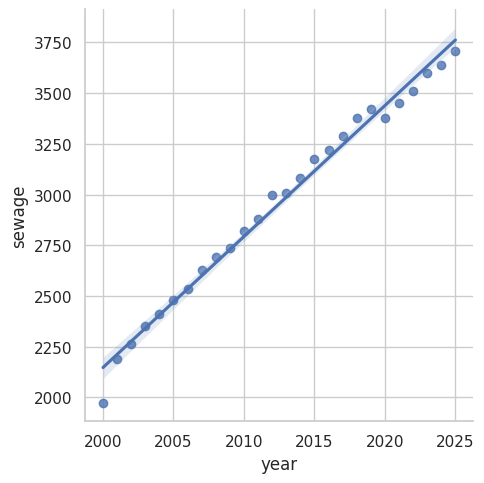

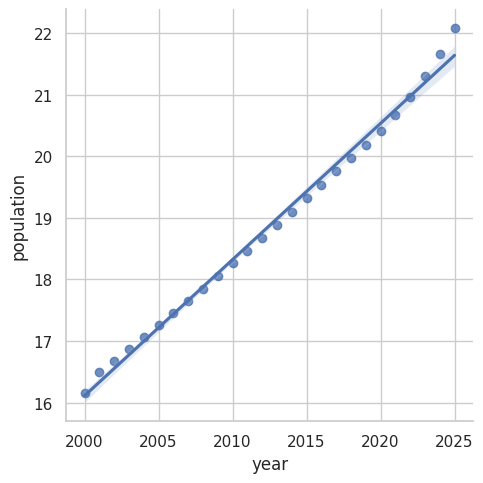

In [683]:
# regression view
sns.lmplot(x='year', y='energy', data=df)
sns.lmplot(x='year', y='water', data=df)
sns.lmplot(x='year', y='waste', data=df)
sns.lmplot(x='year', y='sewage', data=df)
sns.lmplot(x='year', y='population', data=df)

plt.show()

# Machine Learning Models

In [684]:
import numpy as np
import pandas as pd

# Define future years for prediction
future_year = np.array([[year] for year in range(2026, 2031)])

In [685]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

### Population Prediction (using Year)

In [686]:
# Define features (X) and target (y) for population prediction
X_population = df[['year']]
y_population = df['population']

# Split data into training and testing sets
X_population_train, X_population_test, y_population_train, y_population_test = train_test_split(
    X_population, y_population, test_size=0.2, random_state=42
)

# Initialize and train Linear Regression model
lr_population_model = LinearRegression()
lr_population_model.fit(X_population_train, y_population_train)

# Initialize and train Polynomial Regression model (degree=2)
poly_population_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_population_model.fit(X_population_train, y_population_train)

# Make predictions on the test set
lr_population_pred = lr_population_model.predict(X_population_test)
poly_population_pred = poly_population_model.predict(X_population_test)

# Evaluate models
print("--- Linear Regression (Population) ---")
print(f"MAE: {mean_absolute_error(y_population_test, lr_population_pred):.2f}")
print(f"R² Score: {r2_score(y_population_test, lr_population_pred):.2f}")
print("\n--- Polynomial Regression (Population, Degree 2) ---")
print(f"MAE: {mean_absolute_error(y_population_test, poly_population_pred):.2f}")
print(f"R² Score: {r2_score(y_population_test, poly_population_pred):.2f}")


--- Linear Regression (Population) ---
MAE: 0.10
R² Score: 0.99

--- Polynomial Regression (Population, Degree 2) ---
MAE: 0.08
R² Score: 1.00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


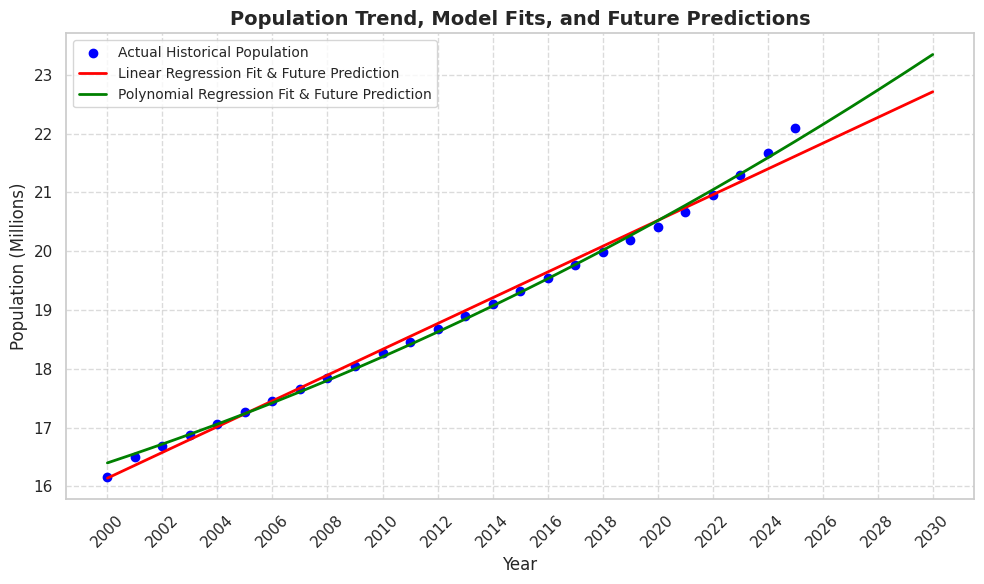

In [687]:
# Combine historical and future years for plotting
all_years = np.concatenate((X_population.values.flatten(), future_year.flatten()))
all_years_sorted = np.sort(np.unique(all_years))

# Predict for the combined range of years using both models
lr_population_all_years = lr_population_model.predict(all_years_sorted.reshape(-1, 1))
poly_population_all_years = poly_population_model.predict(all_years_sorted.reshape(-1, 1))

plt.figure(figsize=(10, 6))
# Plot actual historical data
plt.scatter(X_population, y_population, label='Actual Historical Population', color='blue', zorder=2)

# Plot Linear Regression fit and future prediction
plt.plot(all_years_sorted, lr_population_all_years,
         label='Linear Regression Fit & Future Prediction', color='red', linestyle='-', linewidth=2)

# Plot Polynomial Regression fit and future prediction
plt.plot(all_years_sorted, poly_population_all_years,
         label='Polynomial Regression Fit & Future Prediction', color='green', linestyle='-', linewidth=2)

plt.title("Population Trend, Model Fits, and Future Predictions", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Population (Millions)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(all_years_sorted.min(), all_years_sorted.max() + 1, 2), rotation=45)
plt.tight_layout()
plt.show()

In [688]:
# Use the Polynomial model for future population prediction as it performed slightly better for population
future_year_df = pd.DataFrame(future_year, columns=['year'])
predicted_future_population = poly_population_model.predict(future_year_df).flatten()

# Create a combined DataFrame for all years (historical + future) with population values
historical_population_df = df[['year', 'population']].copy()
future_population_df = pd.DataFrame({'year': future_year.flatten(), 'population': predicted_future_population})
all_population_data = pd.concat([historical_population_df, future_population_df], ignore_index=True).drop_duplicates(subset='year')
all_population_data = all_population_data.sort_values('year').reset_index(drop=True)

# Prepare combined features for resource prediction (historical and future)
all_years_combined = np.concatenate((df['year'].values, future_year.flatten()))
all_years_combined_sorted = np.sort(np.unique(all_years_combined))

X_plot_combined_features = pd.DataFrame({'year': all_years_combined_sorted})
X_plot_combined_features = X_plot_combined_features.merge(all_population_data, on='year', how='left')

### Energy Consumption Prediction (Year and Population)

In [689]:
# Define features (X) and target (y) for energy prediction
X_energy_multi = df[['year', 'population']]
y_energy_multi = df['energy']

# Split data into training and testing sets
X_train_energy, X_test_energy, y_train_energy, y_test_energy = train_test_split(
    X_energy_multi, y_energy_multi, test_size=0.2, random_state=42
)

# Initialize and train Linear Regression model
lr_energy_multi_model = LinearRegression()
lr_energy_multi_model.fit(X_train_energy, y_train_energy)

# Initialize and train Polynomial Regression model (degree=2)
poly_energy_multi_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_energy_multi_model.fit(X_train_energy, y_train_energy)

# Make predictions on the test set
lr_energy_multi_pred = lr_energy_multi_model.predict(X_test_energy)
poly_energy_multi_pred = poly_energy_multi_model.predict(X_test_energy)

# Evaluate models
print("--- Linear Regression (Energy Multi-feature) ---")
print(f"MAE: {mean_absolute_error(y_test_energy, lr_energy_multi_pred):.2f}")
print(f"R² Score: {r2_score(y_test_energy, lr_energy_multi_pred):.2f}")
print("\n--- Polynomial Regression (Energy Multi-feature, Degree 2) ---")
print(f"MAE: {mean_absolute_error(y_test_energy, poly_energy_multi_pred):.2f}")
print(f"R² Score: {r2_score(y_test_energy, poly_energy_multi_pred):.2f}")

--- Linear Regression (Energy Multi-feature) ---
MAE: 138.18
R² Score: 0.99

--- Polynomial Regression (Energy Multi-feature, Degree 2) ---
MAE: 498.36
R² Score: 0.61


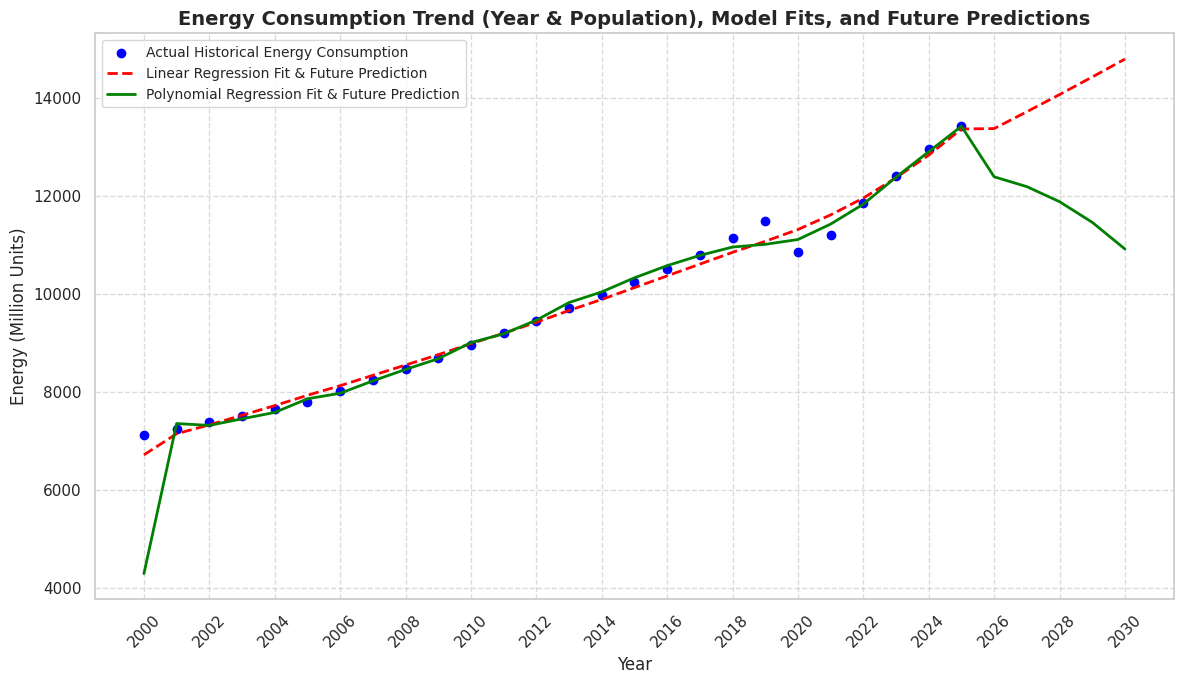

In [690]:
# Predict energy consumption for all years using both models
lr_energy_all_years = lr_energy_multi_model.predict(X_plot_combined_features)
poly_energy_all_years = poly_energy_multi_model.predict(X_plot_combined_features)

plt.figure(figsize=(12, 7))
# Plot actual historical data points
plt.scatter(df['year'], df['energy'], label='Actual Historical Energy Consumption', color='blue', zorder=2)
# Plot Linear Regression fit and future prediction curve
plt.plot(all_years_combined_sorted, lr_energy_all_years, color='red', linestyle='--', label='Linear Regression Fit & Future Prediction', linewidth=2)
# Plot Polynomial Regression fit and future prediction curve
plt.plot(all_years_combined_sorted, poly_energy_all_years, color='green', linestyle='-', label='Polynomial Regression Fit & Future Prediction', linewidth=2)

plt.title("Energy Consumption Trend (Year & Population), Model Fits, and Future Predictions", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Energy (Million Units)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(all_years_combined_sorted.min(), all_years_combined_sorted.max() + 1, 2), rotation=45)
plt.tight_layout()
plt.show()

### Water Consumption Prediction (Year and Population)

In [691]:
# Define features (X) and target (y) for water consumption prediction
X_water_multi = df[['year', 'population']]
y_water_multi = df['water']

# Split data into training and testing sets
X_train_water, X_test_water, y_train_water, y_test_water = train_test_split(
    X_water_multi, y_water_multi, test_size=0.2, random_state=42
)

# Initialize and train Linear Regression model
lr_water_multi_model = LinearRegression()
lr_water_multi_model.fit(X_train_water, y_train_water)

# Initialize and train Polynomial Regression model (degree=2)
poly_water_multi_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_water_multi_model.fit(X_train_water, y_train_water)

# Make predictions on the test set
lr_water_multi_pred = lr_water_multi_model.predict(X_test_water)
poly_water_multi_pred = poly_water_multi_model.predict(X_test_water)

# Evaluate models
print("--- Linear Regression (Water Multi-feature) ---")
print(f"MAE: {mean_absolute_error(y_test_water, lr_water_multi_pred):.2f}")
print(f"R² Score: {r2_score(y_test_water, lr_water_multi_pred):.2f}")
print("\n--- Polynomial Regression (Water Multi-feature, Degree 2) ---")
print(f"MAE: {mean_absolute_error(y_test_water, poly_water_multi_pred):.2f}")
print(f"R² Score: {r2_score(y_test_water, poly_water_multi_pred):.2f}")

--- Linear Regression (Water Multi-feature) ---
MAE: 13.06
R² Score: 1.00

--- Polynomial Regression (Water Multi-feature, Degree 2) ---
MAE: 44.40
R² Score: 0.93


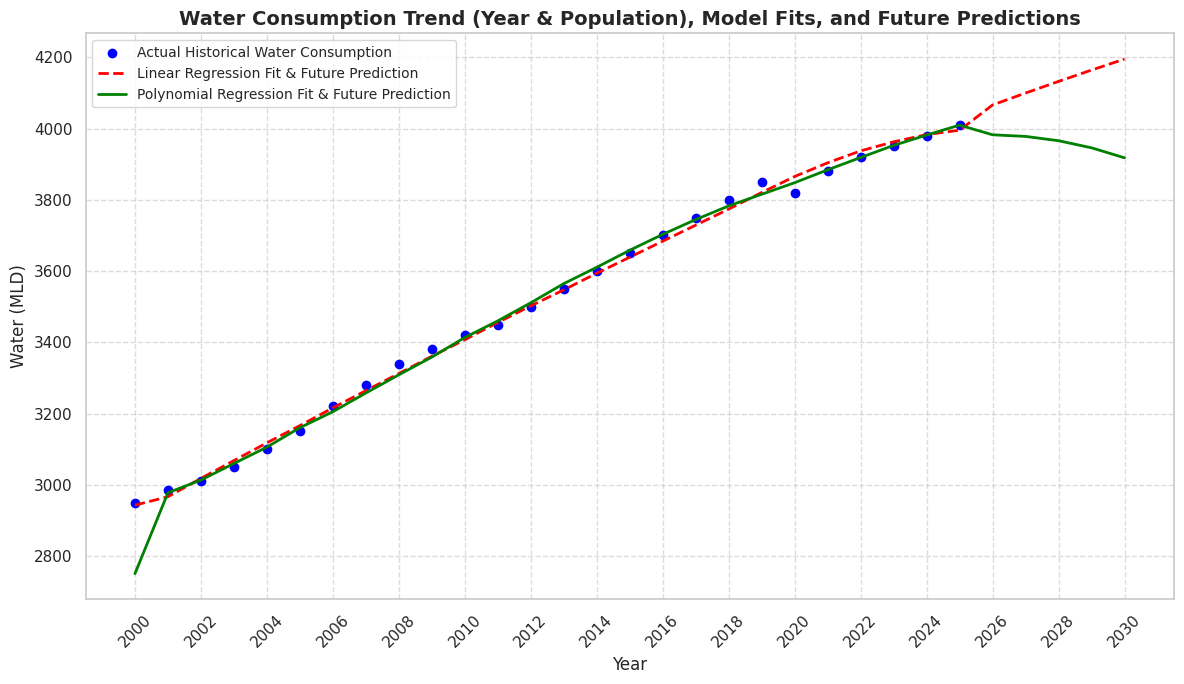

In [692]:
# Predict water consumption for all years using both models
lr_water_all_years = lr_water_multi_model.predict(X_plot_combined_features)
poly_water_all_years = poly_water_multi_model.predict(X_plot_combined_features)

plt.figure(figsize=(12, 7))
# Plot actual historical data points
plt.scatter(df['year'], df['water'], label='Actual Historical Water Consumption', color='blue', zorder=2)
# Plot Linear Regression fit and future prediction curve
plt.plot(all_years_combined_sorted, lr_water_all_years, color='red', linestyle='--', label='Linear Regression Fit & Future Prediction', linewidth=2)
# Plot Polynomial Regression fit and future prediction curve
plt.plot(all_years_combined_sorted, poly_water_all_years, color='green', linestyle='-', label='Polynomial Regression Fit & Future Prediction', linewidth=2)

plt.title("Water Consumption Trend (Year & Population), Model Fits, and Future Predictions", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Water (MLD)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(all_years_combined_sorted.min(), all_years_combined_sorted.max() + 1, 2), rotation=45)
plt.tight_layout()
plt.show()

### Waste Generation Prediction (Year and Population)

In [693]:
# Define features (X) and target (y) for waste generation prediction
X_waste_multi = df[['year', 'population']]
y_waste_multi = df['waste']

# Split data into training and testing sets
X_train_waste, X_test_waste, y_train_waste, y_test_waste = train_test_split(
    X_waste_multi, y_waste_multi, test_size=0.2, random_state=42
)

# Initialize and train Linear Regression model
lr_waste_multi_model = LinearRegression()
lr_waste_multi_model.fit(X_train_waste, y_train_waste)

# Initialize and train Polynomial Regression model (degree=2)
poly_waste_multi_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_waste_multi_model.fit(X_train_waste, y_train_waste)

# Make predictions on the test set
lr_waste_multi_pred = lr_waste_multi_model.predict(X_test_waste)
poly_waste_multi_pred = poly_waste_multi_model.predict(X_test_waste)

# Evaluate models
print("--- Linear Regression (Waste Multi-feature) ---")
print(f"MAE: {mean_absolute_error(y_test_waste, lr_waste_multi_pred):.2f}")
print(f"R² Score: {r2_score(y_test_waste, lr_waste_multi_pred):.2f}")
print("\n--- Polynomial Regression (Waste Multi-feature, Degree 2) ---")
print(f"MAE: {mean_absolute_error(y_test_waste, poly_waste_multi_pred):.2f}")
print(f"R² Score: {r2_score(y_test_waste, poly_waste_multi_pred):.2f}")

--- Linear Regression (Waste Multi-feature) ---
MAE: 656.24
R² Score: 0.42

--- Polynomial Regression (Waste Multi-feature, Degree 2) ---
MAE: 1975.98
R² Score: -11.28


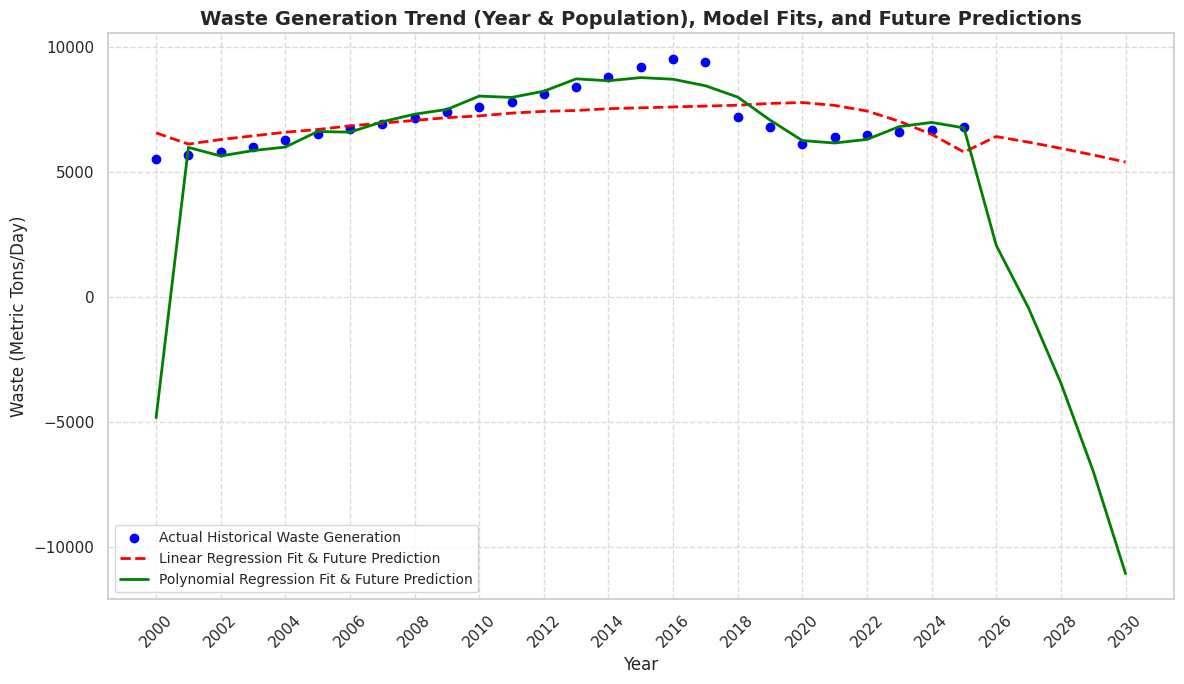

In [694]:
# Predict waste generation for all years using both models
lr_waste_all_years = lr_waste_multi_model.predict(X_plot_combined_features)
poly_waste_all_years = poly_waste_multi_model.predict(X_plot_combined_features)

plt.figure(figsize=(12, 7))
# Plot actual historical data points
plt.scatter(df['year'], df['waste'], label='Actual Historical Waste Generation', color='blue', zorder=2)
# Plot Linear Regression fit and future prediction curve
plt.plot(all_years_combined_sorted, lr_waste_all_years, color='red', linestyle='--', label='Linear Regression Fit & Future Prediction', linewidth=2)
# Plot Polynomial Regression fit and future prediction curve
plt.plot(all_years_combined_sorted, poly_waste_all_years, color='green', linestyle='-', label='Polynomial Regression Fit & Future Prediction', linewidth=2)

plt.title("Waste Generation Trend (Year & Population), Model Fits, and Future Predictions", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Waste (Metric Tons/Day)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(all_years_combined_sorted.min(), all_years_combined_sorted.max() + 1, 2), rotation=45)
plt.tight_layout()
plt.show()

### Sewage Generation Prediction (Year and Population)

In [695]:
# Define features (X) and target (y) for sewage prediction
X_sewage_multi = df[['year', 'population']]
y_sewage_multi = df['sewage']

# Split data into training and testing sets
X_train_sewage, X_test_sewage, y_train_sewage, y_test_sewage = train_test_split(
    X_sewage_multi, y_sewage_multi, test_size=0.2, random_state=42
)

# Initialize and train Linear Regression model
lr_sewage_multi_model = LinearRegression()
lr_sewage_multi_model.fit(X_train_sewage, y_train_sewage)

# Initialize and train Polynomial Regression model (degree=2)
poly_sewage_multi_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_sewage_multi_model.fit(X_train_sewage, y_train_sewage)

# Make predictions on the test set
lr_sewage_multi_pred = lr_sewage_multi_model.predict(X_test_sewage)
poly_sewage_multi_pred = poly_sewage_multi_model.predict(X_test_sewage)

# Evaluate models
print("--- Linear Regression (Sewage Multi-feature) ---")
print(f"MAE: {mean_absolute_error(y_test_sewage, lr_sewage_multi_pred):.2f}")
print(f"R² Score: {r2_score(y_test_sewage, lr_sewage_multi_pred):.2f}")
print("\n--- Polynomial Regression (Sewage Multi-feature, Degree 2) ---")
print(f"MAE: {mean_absolute_error(y_test_sewage, poly_sewage_multi_pred):.2f}")
print(f"R² Score: {r2_score(y_test_sewage, poly_sewage_multi_pred):.2f}")

--- Linear Regression (Sewage Multi-feature) ---
MAE: 40.50
R² Score: 0.98

--- Polynomial Regression (Sewage Multi-feature, Degree 2) ---
MAE: 30.94
R² Score: 0.99


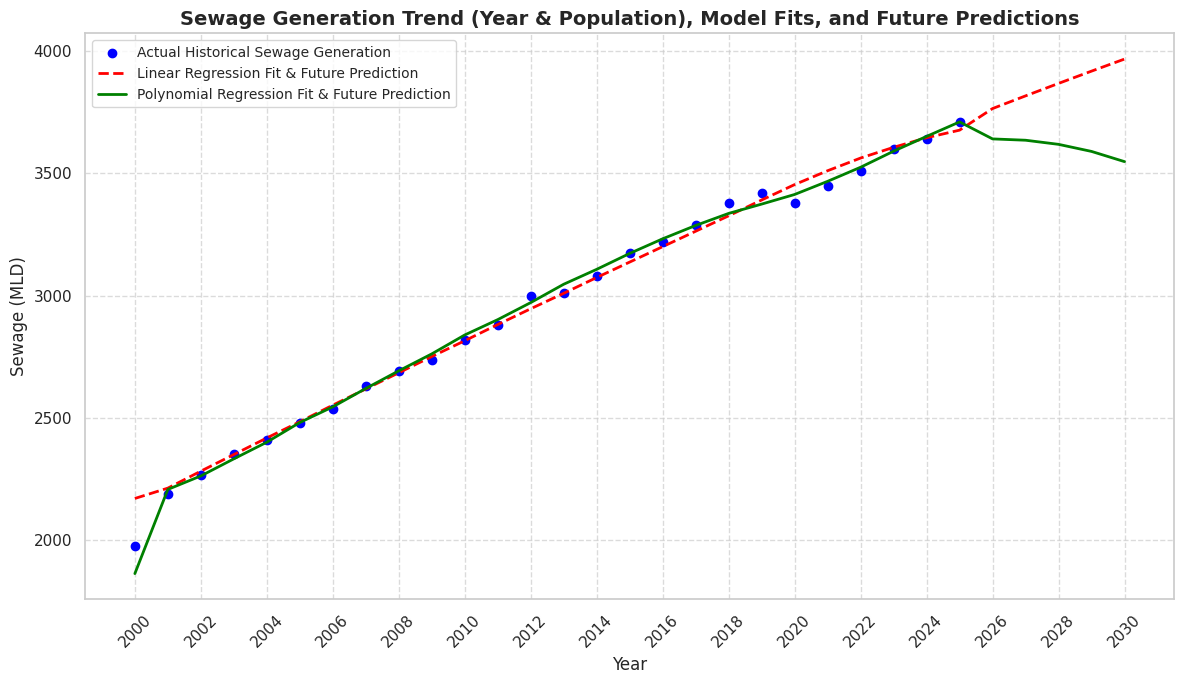

In [696]:
# Predict sewage generation for all years using both models
lr_sewage_all_years = lr_sewage_multi_model.predict(X_plot_combined_features)
poly_sewage_all_years = poly_sewage_multi_model.predict(X_plot_combined_features)

plt.figure(figsize=(12, 7))
# Plot actual historical data points
plt.scatter(df['year'], df['sewage'], label='Actual Historical Sewage Generation', color='blue', zorder=2)
# Plot Linear Regression fit and future prediction curve
plt.plot(all_years_combined_sorted, lr_sewage_all_years, color='red', linestyle='--', label='Linear Regression Fit & Future Prediction', linewidth=2)
# Plot Polynomial Regression fit and future prediction curve
plt.plot(all_years_combined_sorted, poly_sewage_all_years, color='green', linestyle='-', label='Polynomial Regression Fit & Future Prediction', linewidth=2)

plt.title("Sewage Generation Trend (Year & Population), Model Fits, and Future Predictions", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Sewage (MLD)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(all_years_combined_sorted.min(), all_years_combined_sorted.max() + 1, 2), rotation=45)
plt.tight_layout()
plt.show()

In [697]:
import pandas as pd

# Create a DataFrame to store all future predictions
future_predictions_df = pd.DataFrame({'Year': future_year.flatten()})

# Prepare input for future predictions using the predicted population values
future_input_features = pd.DataFrame({
    'year': future_year.flatten(),
    'population': predicted_future_population
})

# Add predictions from Linear Regression models with units in column names
future_predictions_df['Population (Millions)_LR'] = lr_population_model.predict(future_year_df)
future_predictions_df['Energy (Million Units)_LR'] = lr_energy_multi_model.predict(future_input_features)
future_predictions_df['Water (MLD)_LR'] = lr_water_multi_model.predict(future_input_features)
future_predictions_df['Waste (Metric Tons/Day)_LR'] = lr_waste_multi_model.predict(future_input_features)
future_predictions_df['Sewage (MLD)_LR'] = lr_sewage_multi_model.predict(future_input_features)

# Add predictions from Polynomial Regression models with units in column names
future_predictions_df['Population (Millions)_Poly'] = poly_population_model.predict(future_year_df)
future_predictions_df['Energy (Million Units)_Poly'] = poly_energy_multi_model.predict(future_input_features)
future_predictions_df['Water (MLD)_Poly'] = poly_water_multi_model.predict(future_input_features)
future_predictions_df['Waste (Metric Tons/Day)_Poly'] = poly_waste_multi_model.predict(future_input_features)
future_predictions_df['Sewage (MLD)_Poly'] = poly_sewage_multi_model.predict(future_input_features)

# Display the DataFrame
print("Future Predicted Values (2026-2030):")
print(future_predictions_df.round(2).to_string())

# Save to CSV
future_predictions_df.to_csv('future_predictions.csv', index=False)
print("\nFuture predictions saved to 'future_predictions.csv'")

Future Predicted Values (2026-2030):
   Year  Population (Millions)_LR  Energy (Million Units)_LR  Water (MLD)_LR  Waste (Metric Tons/Day)_LR  Sewage (MLD)_LR  Population (Millions)_Poly  Energy (Million Units)_Poly  Water (MLD)_Poly  Waste (Metric Tons/Day)_Poly  Sewage (MLD)_Poly
0  2026                     21.83                   13372.53         4066.10                     6402.51          3765.09                       22.15                     12388.86           3982.38                       2046.40            3640.86
1  2027                     22.05                   13715.82         4099.55                     6176.05          3816.94                       22.44                     12187.84           3977.83                       -458.80            3635.46
2  2028                     22.27                   14066.61         4132.17                     5930.60          3867.96                       22.74                     11880.96           3965.75                      -3454.4

In [698]:
import pandas as pd

final_predictions_df = pd.read_csv('future_predictions.csv')
display(final_predictions_df.head())

,Year,Population (Millions)_LR,Energy (Million Units)_LR,Water (MLD)_LR,Waste (Metric Tons/Day)_LR,Sewage (MLD)_LR,Population (Millions)_Poly,Energy (Million Units)_Poly,Water (MLD)_Poly,Waste (Metric Tons/Day)_Poly,Sewage (MLD)_Poly
0,2026,21.833982,13372.525280,4066.095314,6402.512216,3765.088850,22.151919,12388.861591,3982.376515,2046.396812,3640.862981
1,2027,22.053030,13715.819775,4099.551892,6176.049957,3816.935109,22.442254,12187.837195,3977.826580,-458.803864,3635.462361
2,2028,22.272078,14066.613630,4132.171563,5930.603869,3867.963700,22.737703,11880.963400,3965.746314,-3454.456267,3618.623129
3,2029,22.491126,14424.906844,4163.954326,5666.173951,3918.174622,23.038266,11459.584695,3945.822919,-6979.510104,3589.663598
4,2030,22.710174,14790.699416,4194.900182,5382.760204,3967.567876,23.343942,10915.045748,3917.766829,-11073.391764,3547.914096


### Energy Consumption Prediction (Year Only)

In [699]:
# Define features (X) and target (y) for year-wise energy prediction
X_energy_year = df[['year']]
y_energy_year = df['energy']

# Split data into training and testing sets
X_train_energy_year, X_test_energy_year, y_train_energy_year, y_test_energy_year = train_test_split(
    X_energy_year, y_energy_year, test_size=0.2, random_state=42
)

# Initialize and train Linear Regression model
lr_energy_year_model = LinearRegression()
lr_energy_year_model.fit(X_train_energy_year, y_train_energy_year)

# Initialize and train Polynomial Regression model (degree=2)
poly_energy_year_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_energy_year_model.fit(X_train_energy_year, y_train_energy_year)

# Make predictions on the test set
lr_energy_year_pred = lr_energy_year_model.predict(X_test_energy_year)
poly_energy_year_pred = poly_energy_year_model.predict(X_test_energy_year)

# Evaluate models
print("--- Linear Regression (Energy Year-wise) ---")
print(f"MAE: {mean_absolute_error(y_test_energy_year, lr_energy_year_pred):.2f}")
print(f"R² Score: {r2_score(y_test_energy_year, lr_energy_year_pred):.2f}")
print("\n--- Polynomial Regression (Energy Year-wise, Degree 2) ---")
print(f"MAE: {mean_absolute_error(y_test_energy_year, poly_energy_year_pred):.2f}")
print(f"R² Score: {r2_score(y_test_energy_year, poly_energy_year_pred):.2f}")

--- Linear Regression (Energy Year-wise) ---
MAE: 227.11
R² Score: 0.98

--- Polynomial Regression (Energy Year-wise, Degree 2) ---
MAE: 103.24
R² Score: 0.99


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


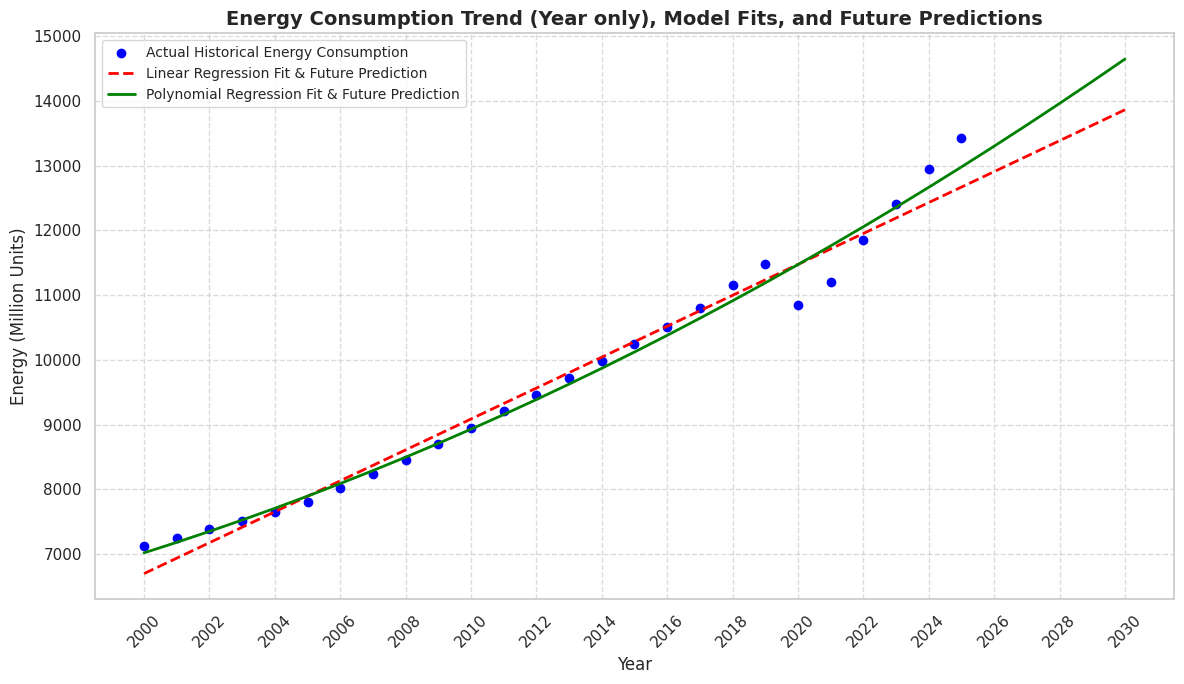

In [700]:
# Combine historical and future years for plotting
all_years_energy = np.concatenate((X_energy_year.values.flatten(), future_year.flatten()))
all_years_energy_sorted = np.sort(np.unique(all_years_energy))

# Predict energy consumption for all years using both models
lr_energy_all_years_year = lr_energy_year_model.predict(all_years_energy_sorted.reshape(-1, 1))
poly_energy_all_years_year = poly_energy_year_model.predict(all_years_energy_sorted.reshape(-1, 1))

plt.figure(figsize=(12, 7))
# Plot actual historical data points
plt.scatter(df['year'], df['energy'], label='Actual Historical Energy Consumption', color='blue', zorder=2)
# Plot Linear Regression fit and future prediction curve
plt.plot(all_years_energy_sorted, lr_energy_all_years_year, color='red', linestyle='--', label='Linear Regression Fit & Future Prediction', linewidth=2)
# Plot Polynomial Regression fit and future prediction curve
plt.plot(all_years_energy_sorted, poly_energy_all_years_year, color='green', linestyle='-', label='Polynomial Regression Fit & Future Prediction', linewidth=2)

plt.title("Energy Consumption Trend (Year only), Model Fits, and Future Predictions", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Energy (Million Units)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(all_years_energy_sorted.min(), all_years_energy_sorted.max() + 1, 2), rotation=45)
plt.tight_layout()
plt.show()

### Water Consumption Prediction (Year Only)

In [701]:
# Define features (X) and target (y) for year-wise water prediction
X_water_year = df[['year']]
y_water_year = df['water']

# Split data into training and testing sets
X_train_water_year, X_test_water_year, y_train_water_year, y_test_water_year = train_test_split(
    X_water_year, y_water_year, test_size=0.2, random_state=42
)

# Initialize and train Linear Regression model
lr_water_year_model = LinearRegression()
lr_water_year_model.fit(X_train_water_year, y_train_water_year)

# Initialize and train Polynomial Regression model (degree=2)
poly_water_year_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_water_year_model.fit(X_train_water_year, y_train_water_year)

# Make predictions on the test set
lr_water_year_pred = lr_water_year_model.predict(X_test_water_year)
poly_water_year_pred = poly_water_year_model.predict(X_test_water_year)

# Evaluate models
print("--- Linear Regression (Water Year-wise) ---")
print(f"MAE: {mean_absolute_error(y_test_water_year, lr_water_year_pred):.2f}")
print(f"R² Score: {r2_score(y_test_water_year, lr_water_year_pred):.2f}")
print("\n--- Polynomial Regression (Water Year-wise, Degree 2) ---")
print(f"MAE: {mean_absolute_error(y_test_water_year, poly_water_year_pred):.2f}")
print(f"R² Score: {r2_score(y_test_water_year, poly_water_year_pred):.2f}")

--- Linear Regression (Water Year-wise) ---
MAE: 26.32
R² Score: 0.99

--- Polynomial Regression (Water Year-wise, Degree 2) ---
MAE: 19.72
R² Score: 0.99


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


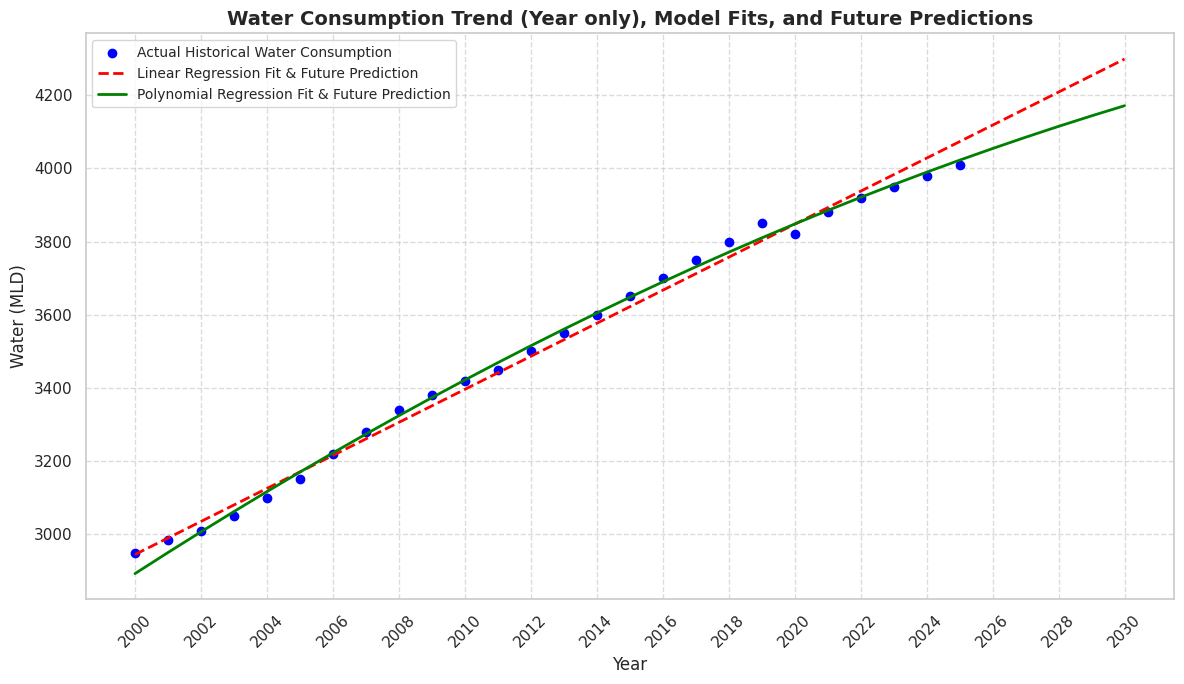

In [702]:
# Combine historical and future years for plotting
all_years_water = np.concatenate((X_water_year.values.flatten(), future_year.flatten()))
all_years_water_sorted = np.sort(np.unique(all_years_water))

# Predict water consumption for all years using both models
lr_water_all_years_year = lr_water_year_model.predict(all_years_water_sorted.reshape(-1, 1))
poly_water_all_years_year = poly_water_year_model.predict(all_years_water_sorted.reshape(-1, 1))

plt.figure(figsize=(12, 7))
# Plot actual historical data points
plt.scatter(df['year'], df['water'], label='Actual Historical Water Consumption', color='blue', zorder=2)
# Plot Linear Regression fit and future prediction curve
plt.plot(all_years_water_sorted, lr_water_all_years_year, color='red', linestyle='--', label='Linear Regression Fit & Future Prediction', linewidth=2)
# Plot Polynomial Regression fit and future prediction curve
plt.plot(all_years_water_sorted, poly_water_all_years_year, color='green', linestyle='-', label='Polynomial Regression Fit & Future Prediction', linewidth=2)

plt.title("Water Consumption Trend (Year only), Model Fits, and Future Predictions", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Water (MLD)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(all_years_water_sorted.min(), all_years_water_sorted.max() + 1, 2), rotation=45)
plt.tight_layout()
plt.show()

### Waste Generation Prediction (Year Only)

In [703]:
# Define features (X) and target (y) for year-wise waste prediction
X_waste_year = df[['year']]
y_waste_year = df['waste']

# Split data into training and testing sets
X_train_waste_year, X_test_waste_year, y_train_waste_year, y_test_waste_year = train_test_split(
    X_waste_year, y_waste_year, test_size=0.2, random_state=42
)

# Initialize and train Linear Regression model
lr_waste_year_model = LinearRegression()
lr_waste_year_model.fit(X_train_waste_year, y_train_waste_year)

# Initialize and train Polynomial Regression model (degree=2)
poly_waste_year_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_waste_year_model.fit(X_train_waste_year, y_train_waste_year)

# Make predictions on the test set
lr_waste_year_pred = lr_waste_year_model.predict(X_test_waste_year)
poly_waste_year_pred = poly_waste_year_model.predict(X_test_waste_year)

# Evaluate models
print("--- Linear Regression (Waste Year-wise) ---")
print(f"MAE: {mean_absolute_error(y_test_waste_year, lr_waste_year_pred):.2f}")
print(f"R² Score: {r2_score(y_test_waste_year, lr_waste_year_pred):.2f}")
print("\n--- Polynomial Regression (Waste Year-wise, Degree 2) ---")
print(f"MAE: {mean_absolute_error(y_test_waste_year, poly_waste_year_pred):.2f}")
print(f"R² Score: {r2_score(y_test_waste_year, poly_waste_year_pred):.2f}")

--- Linear Regression (Waste Year-wise) ---
MAE: 958.42
R² Score: 0.08

--- Polynomial Regression (Waste Year-wise, Degree 2) ---
MAE: 602.26
R² Score: 0.62


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


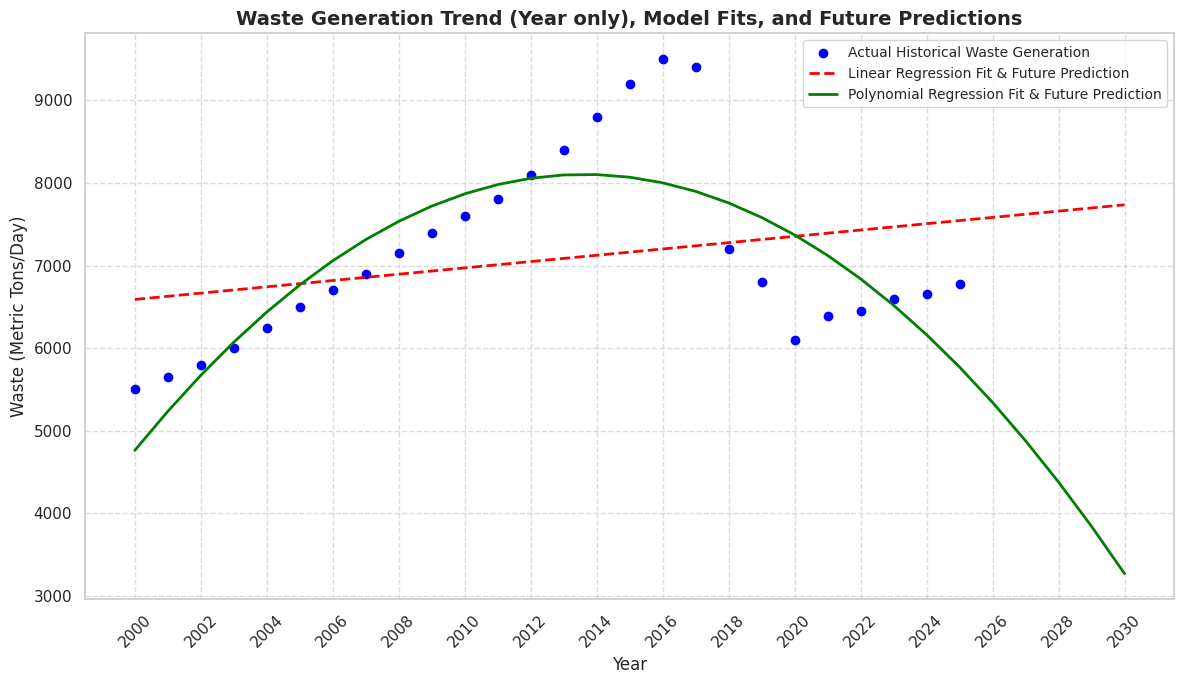

In [704]:
# Combine historical and future years for plotting
all_years_waste = np.concatenate((X_waste_year.values.flatten(), future_year.flatten()))
all_years_waste_sorted = np.sort(np.unique(all_years_waste))

# Predict waste generation for all years using both models
lr_waste_all_years_year = lr_waste_year_model.predict(all_years_waste_sorted.reshape(-1, 1))
poly_waste_all_years_year = poly_waste_year_model.predict(all_years_waste_sorted.reshape(-1, 1))

plt.figure(figsize=(12, 7))
# Plot actual historical data points
plt.scatter(df['year'], df['waste'], label='Actual Historical Waste Generation', color='blue', zorder=2)
# Plot Linear Regression fit and future prediction curve
plt.plot(all_years_waste_sorted, lr_waste_all_years_year, color='red', linestyle='--', label='Linear Regression Fit & Future Prediction', linewidth=2)
# Plot Polynomial Regression fit and future prediction curve
plt.plot(all_years_waste_sorted, poly_waste_all_years_year, color='green', linestyle='-', label='Polynomial Regression Fit & Future Prediction', linewidth=2)

plt.title("Waste Generation Trend (Year only), Model Fits, and Future Predictions", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Waste (Metric Tons/Day)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(all_years_waste_sorted.min(), all_years_waste_sorted.max() + 1, 2), rotation=45)
plt.tight_layout()
plt.show()

### Sewage Generation Prediction (Year Only)

In [705]:
# Define features (X) and target (y) for year-wise sewage prediction
X_sewage_year = df[['year']]
y_sewage_year = df['sewage']

# Split data into training and testing sets
X_train_sewage_year, X_test_sewage_year, y_train_sewage_year, y_test_sewage_year = train_test_split(
    X_sewage_year, y_sewage_year, test_size=0.2, random_state=42
)

# Initialize and train Linear Regression model
lr_sewage_year_model = LinearRegression()
lr_sewage_year_model.fit(X_train_sewage_year, y_train_sewage_year)

# Initialize and train Polynomial Regression model (degree=2)
poly_sewage_year_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_sewage_year_model.fit(X_train_sewage_year, y_train_sewage_year)

# Make predictions on the test set
lr_sewage_year_pred = lr_sewage_year_model.predict(X_test_sewage_year)
poly_sewage_year_pred = poly_sewage_year_model.predict(X_test_sewage_year)

# Evaluate models
print("--- Linear Regression (Sewage Year-wise) ---")
print(f"MAE: {mean_absolute_error(y_test_sewage_year, lr_sewage_year_pred):.2f}")
print(f"R² Score: {r2_score(y_test_sewage_year, lr_sewage_year_pred):.2f}")
print("\n--- Polynomial Regression (Sewage Year-wise, Degree 2) ---")
print(f"MAE: {mean_absolute_error(y_test_sewage_year, poly_sewage_year_pred):.2f}")
print(f"R² Score: {r2_score(y_test_sewage_year, poly_sewage_year_pred):.2f}")

--- Linear Regression (Sewage Year-wise) ---
MAE: 52.25
R² Score: 0.97

--- Polynomial Regression (Sewage Year-wise, Degree 2) ---
MAE: 34.25
R² Score: 0.99


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


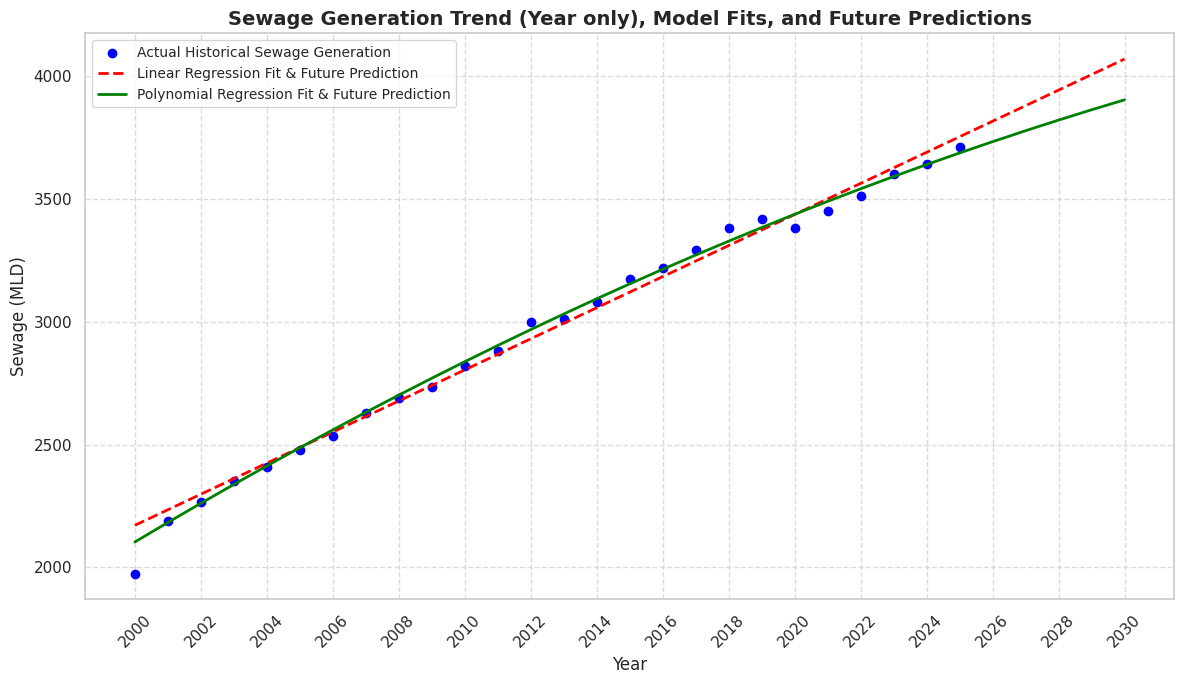

In [706]:
# Combine historical and future years for plotting
all_years_sewage = np.concatenate((X_sewage_year.values.flatten(), future_year.flatten()))
all_years_sewage_sorted = np.sort(np.unique(all_years_sewage))

# Predict sewage generation for all years using both models
lr_sewage_all_years_year = lr_sewage_year_model.predict(all_years_sewage_sorted.reshape(-1, 1))
poly_sewage_all_years_year = poly_sewage_year_model.predict(all_years_sewage_sorted.reshape(-1, 1))

plt.figure(figsize=(12, 7))
# Plot actual historical data points
plt.scatter(df['year'], df['sewage'], label='Actual Historical Sewage Generation', color='blue', zorder=2)
# Plot Linear Regression fit and future prediction curve
plt.plot(all_years_sewage_sorted, lr_sewage_all_years_year, color='red', linestyle='--', label='Linear Regression Fit & Future Prediction', linewidth=2)
# Plot Polynomial Regression fit and future prediction curve
plt.plot(all_years_sewage_sorted, poly_sewage_all_years_year, color='green', linestyle='-', label='Polynomial Regression Fit & Future Prediction', linewidth=2)

plt.title("Sewage Generation Trend (Year only), Model Fits, and Future Predictions", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Sewage (MLD)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(all_years_sewage_sorted.min(), all_years_sewage_sorted.max() + 1, 2), rotation=45)
plt.tight_layout()
plt.show()

In [707]:
# Create a DataFrame to store all future predictions from year-wise models
future_predictions_year_only_df = pd.DataFrame({'Year': future_year.flatten()})

# Add predictions from Linear Regression models with units in column names
future_predictions_year_only_df['Energy (Million Units)_LR_YearOnly'] = lr_energy_year_model.predict(future_year_df)
future_predictions_year_only_df['Water (MLD)_LR_YearOnly'] = lr_water_year_model.predict(future_year_df)
future_predictions_year_only_df['Waste (Metric Tons/Day)_LR_YearOnly'] = lr_waste_year_model.predict(future_year_df)
future_predictions_year_only_df['Sewage (MLD)_LR_YearOnly'] = lr_sewage_year_model.predict(future_year_df)

# Add predictions from Polynomial Regression models with units in column names
future_predictions_year_only_df['Energy (Million Units)_Poly_YearOnly'] = poly_energy_year_model.predict(future_year_df)
future_predictions_year_only_df['Water (MLD)_Poly_YearOnly'] = poly_water_year_model.predict(future_year_df)
future_predictions_year_only_df['Waste (Metric Tons/Day)_Poly_YearOnly'] = poly_waste_year_model.predict(future_year_df)
future_predictions_year_only_df['Sewage (MLD)_Poly_YearOnly'] = poly_sewage_year_model.predict(future_year_df)

# Display the DataFrame
print("Future Predicted Values (2026-2030) - Year Only Models:")
print(future_predictions_year_only_df.round(2).to_string())

# Save to CSV
future_predictions_year_only_df.to_csv('future_predictions_year_only.csv', index=False)
print("\nFuture predictions from year-only models saved to 'future_predictions_year_only.csv'")

Future Predicted Values (2026-2030) - Year Only Models:
   Year  Energy (Million Units)_LR_YearOnly  Water (MLD)_LR_YearOnly  Waste (Metric Tons/Day)_LR_YearOnly  Sewage (MLD)_LR_YearOnly  Energy (Million Units)_Poly_YearOnly  Water (MLD)_Poly_YearOnly  Waste (Metric Tons/Day)_Poly_YearOnly  Sewage (MLD)_Poly_YearOnly
0  2026                            12906.24                  4118.13                              7582.86                   3815.93                              13299.15                    4054.17                                5342.95                     3732.66
1  2027                            13144.99                  4163.26                              7621.05                   3879.17                              13625.99                    4084.95                                4878.92                     3777.23
2  2028                            13383.73                  4208.38                              7659.25                   3942.42                     